# Uke 42:



## Oppgave 1

* Lag dataframen vist under
<img src="https://folk.ntnu.no/jonajh/iira2001/42/img/oppgave1.png">

* Programmet er påbegynt under
* Merk at det trekkes tilfeldige tall, slik at tallverdiene ikke blir nøyaktig de samme som på figuren

*Tips:* For å formatere heltall til 2 plasser med innledende nuller i en f-streng: 
`f"heltallet mitt er {tall:02d}"`

In [2]:
import numpy as np
import pandas as pd

n = 180
populasjon = np.random.normal(10.0,0.1,n) # Trekker tilfeldige tall med normalfordeling rundt 10
arbeidsledighet = np.random.normal(0.03,0.002,n) # Trekker tilfeldig arbeidsledighet, normalfordelt
indeks = [f"{y}M{m:02d}" 
          for y in range(1990,2005) 
          for m in range(1,13)]

arbeidsledighet_formatert = [f"{round(ledighet*100,2)}%" for ledighet in arbeidsledighet]
arbeidsledige = [int(pop*ledighet*1000) for pop,ledighet in zip(populasjon, arbeidsledighet)]

df = pd.DataFrame({"Populasjon(million)": [round(p,2) for p in populasjon], 
                   "Arbeidsledighet": arbeidsledighet_formatert, 
                   "Antall uten arbeid(tusen)": arbeidsledige},
                 index = indeks)
df

,Populasjon(million),Arbeidsledighet,Antall uten arbeid(tusen)
1990M01,10.11,2.71%,274
1990M02,9.99,3.25%,325
1990M03,10.10,2.69%,271
1990M04,10.16,3.56%,362
1990M05,9.93,3.28%,325
...,...,...,...
2004M08,10.16,2.88%,292
2004M09,10.16,3.46%,351
2004M10,9.96,2.9%,289
2004M11,10.03,3.11%,312


# Oppgave 2

Vi skal lage en funksjon som hjelper oss med å omgjøre dataframes med data for hver måned til hvert kvartal
og hvert kvartal til hvert år.

* Anta at tidene er på formene:
    - yyyyKq feks 1983K2 for  andre kvartal 1983
    - yyyyMmm feks 2001M03 for mars (måned 3) i 2001
    - yyyy feks 2020
* Lag to funksjoner:
    - Det ene tar et dataframe med index på månedsformen og gir tilbake et på kvartalsformen
    - Den andre funksjonen tar et dataframe med index på kvartalsformen og gir tilbake et på «årsformen»

Anta først at dataframen kun har 1 kolonne. Når du har fått det til kan du gjøre om funksjonen slik at den
fungerer med flere kolonner.

Et par ting å ta hensyn til/problemer å løse:

* Noen ganger gir det mening å legge sammen dataene fra månedene i et kvartal, feks ved åpnede konkurser
* Andre ganger må man gjøre noe annet, feks ved arbeidsledighet
* Hvordan lage en funksjon som tar hensyn til dette ved kun 1 kolonne og ved flere kolonner?
* Hva med kolonner som gir prosent som en streng `"2.1%"`i stedet for `0.021`, kan vi tilpasse funksjonen?

Du kan teste funksjonene dine på datasettene fra torsdagstimen, eller finne noen andre på ssb

    

In [26]:
arbeidsledige_df = pd.read_csv("08518_20231018-095706.csv", sep="\t")
konkurser_df = pd.read_csv("09695_20231018-104409.csv", sep="\t", encoding="ISO-8859-1")

def quarter2year(df, kumulativ=[]):
    indeks = df.index
    n = len(indeks)
    start = 0
    while not "K1" in indeks[start]:
        start += 1
    new_index = list({year[:4] for year in indeks[start:]})
    new_indes = new_index.sort()
    new_df = pd.DataFrame({}, index=new_index)
    for c in df.columns:
        if c in kumulativ:
            new_col = [sum(df[c][i:i+4]) for i in range(start,n,4) ]
        else:
            new_col = [sum(df[c][i:i+4])/4 for i in range(start,n,4) ]
        new_df[c] = new_col
    return new_df#.sort_index()

def month2quarter(df, kumulativ=[]):
    indeks = df.index
    n = len(indeks)
    kvartalstart = {"M01": "K1", "M04": "K2", "M07": "K3", "M10": "K4"}
    start = 0
    while not indeks[start][-3:] in kvartalstart.keys():
        start += 1
    start_kvartal = kvartalstart[indeks[start][-3:]]
    new_index = [f"{ym[:4]}{kvartalstart[ym[-3:]]}" for ym in indeks[start::3]]
    new_df = pd.DataFrame({}, index=new_index)
    for c in df.columns:
        if c in kumulativ:
            new_col = [sum(df[c][i:i+3]) for  i in range(start,n,3)]
        else:
            new_col = [sum(df[c][i:i+3]/3) for  i in range(start,n,3)]
        new_df[c] = new_col
    return new_df
    



arbeidsledige_df.set_index("kvartal", inplace=True)
quarter2year(arbeidsledige_df)

konkurser_df.set_index("måned", inplace=True)
konkurser_kvartal_df = month2quarter(konkurser_df, kumulativ=["Opna konkursar"])
df1 = arbeidsledige_df.join(konkurser_kvartal_df)
df2 = quarter2year(arbeidsledige_df).join(quarter2year(konkurser_kvartal_df, kumulativ=["Opna konkursar"]))
df1

,Arbeidsledige (1 000 personer),Opna konkursar
kvartal,,
1972K1,24,NaN
1972K2,26,NaN
1972K3,31,NaN
1972K4,31,NaN
1973K1,22,NaN
...,...,...
2022K2,98,934.0
2022K3,96,835.0
2022K4,92,1006.0


# Oppgave 3

Finn et datasett du synes er spennende på ssb og test ut det vi har jobbet med i timen:
* Last inn med read_csv
* Slå opp på forskjellige datapunkt, velg ut rader/kolonner (`.loc`, `.iloc`, `["kolonnenavn"]`)
* Velg ut deler av datasettets rader med å slice (feks df.loc[1:10])
* Skift navn på kolonner/rader/index (.rename(...))
* Plotte data



# Oppgave 4

Se om du klarer å lese i dokumentasjon/tutorials/cheat sheet og finne ut følgende som vi ikke har gjort i timen:
* Plotte histogram (prøv feks å plotte kolonner/ene i oppgave 1 som histogram)
* Velge ut deler av dataframe med og slice index OG velge ut deler av kolonnene


,Arbeidsledighet,Antall uten arbeid(tusen)
1990M03,2.69%,271
1990M04,3.56%,362
1990M05,3.28%,325
1990M06,3.12%,313
1990M07,3.16%,317
1990M08,3.17%,318
1990M09,3.15%,311
1990M10,2.62%,260
1990M11,2.97%,297
1990M12,2.93%,289


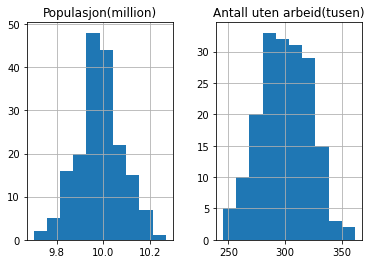

In [48]:
df.hist()

#Slice indeks og kolonne:
df.loc[slice("1990M03","1991M04"),["Arbeidsledighet", "Antall uten arbeid(tusen)"]]

# Oppgave 5

Prøv å regne ut korrelasjon mellom størrelser fra 2 ulike datasett fra ssb.




,Arbeidsledige (1 000 personer),Opna konkursar
Arbeidsledige (1 000 personer),1.000000,0.797476
Opna konkursar,0.797476,1.000000


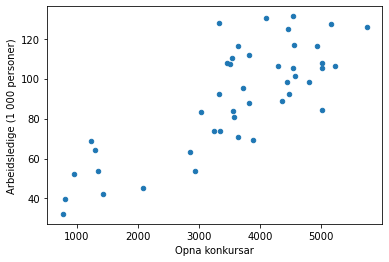

In [31]:
df2.plot.scatter(x="Opna konkursar", y="Arbeidsledige (1 000 personer)")
df2.corr()